# 03  Rapid intensification

This notebook tests whether rapid intensification has become more common since 1988.

A storm is treated as experiencing rapid intensification if it has at least one 24-hour wind-speed increase of 30 kt or more. This is a different risk channel from peak intensity. RI affects forecast uncertainty, preparation time, evacuation planning, and claims readiness.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

# Bootstrap settings
RNG = np.random.default_rng(42)
N_BOOTSTRAP = 1000

MIN_STORMS_PER_YEAR = 3


ANALYSIS_BASINS = ['WP', 'EP', 'NA', 'SI', 'SP']

In [12]:
storms = pd.read_parquet('../data/processed/storms_analysis.parquet')

START_YEAR = 1988
END_YEAR = 2023

storms = storms[
    storms["basin"].isin(ANALYSIS_BASINS)
    & storms["year"].between(START_YEAR, END_YEAR)
].copy()

print(f"Loaded {len(storms):,} storms across {storms['basin'].nunique()} basins")
print(f"Year range: {storms['year'].min()} to {storms['year'].max()}")

basin_counts = (
    storms.groupby("basin")
    .size()
    .reindex(ANALYSIS_BASINS)
    .rename("n_storms")
    .to_frame()
)

display(basin_counts)

Loaded 2,424 storms across 5 basins
Year range: 1988 to 2023


,n_storms
basin,
WP,851
EP,497
NA,411
SI,435
SP,230


### Rapid intensification definition

The processed storm-level file contains an experienced_RI flag built during preprocessing from the 6-hourly track records. It marks storms with at least one 24-hour wind-speed increase of 30 kt or more.
As a sanity check, the full-period RI share by basin is shown first, before testing for trends.

In [13]:
# Full-period RI share by basin

ri_rate = (
    storms.groupby("basin")["experienced_RI"]
    .mean()
    .mul(100)
    .round(1)
    .reindex(ANALYSIS_BASINS)
    .rename("RI share (%)")
    .to_frame()
)

display(ri_rate)

,RI share (%)
basin,
WP,21.0
EP,43.5
NA,37.5
SI,33.8
SP,34.8


### Exploratory period view
Storms grouped into broad periods first, to see whether later periods differ from earlier ones. Error bars show bootstrap 95% CIs.

In [14]:
def bootstrap_fraction(values, n_boot=N_BOOTSTRAP, ci=95, rng=RNG):
    """Bootstrap CI for a binary proportion, returned as percentages."""
    values = np.asarray(values, dtype=bool)
    n = len(values)
    
    if n == 0:
        return np.nan, np.nan, np.nan
    
    point = values.mean() * 100
    indices = rng.integers(0, n, size=(n_boot, n))
    boot_means = values[indices].mean(axis=1) * 100
    
    alpha = (100 - ci) / 2
    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)
    
    return point, lower, upper

In [15]:
# Broad-period RI share with bootstrap confidence intervals

rows = []

for basin in ANALYSIS_BASINS:
    basin_storms = storms[storms["basin"] == basin]
    
    for decade in sorted(basin_storms["decade"].unique()):
        period_storms = basin_storms[basin_storms["decade"] == decade]
        
        if len(period_storms) < 10:
            continue
        
        point, lower, upper = bootstrap_fraction(period_storms["experienced_RI"])
        
        rows.append({
            "basin": basin,
            "decade": decade,
            "n_storms": len(period_storms),
            "ri_share": point,
            "ci_lower": lower,
            "ci_upper": upper
        })

decadal_ri = pd.DataFrame(rows)

In [16]:
def label_period(decade):
    if decade == 1980:
        return "1988–1989"
    if decade == 2020:
        return "2020–2023"
    return f"{decade}s"
    
ri_display = decadal_ri.copy()
ri_display["period"] = ri_display["decade"].apply(label_period)

ri_display["95% CI"] = (
    ri_display["ci_lower"].map(lambda x: f"{x:.1f}")
    + "–"
    + ri_display["ci_upper"].map(lambda x: f"{x:.1f}")
)

ri_display = ri_display[
    ["basin", "period", "n_storms", "ri_share", "95% CI"]
].rename(columns={
    "basin": "Basin",
    "period": "Period",
    "n_storms": "Storms",
    "ri_share": "RI share (%)"
})

display(
    ri_display.style
    .hide(axis="index")
    .format({
        "RI share (%)": "{:.1f}",
        "Storms": "{:.0f}"
    })
)

Basin,Period,Storms,RI share (%),95% CI
WP,1988–1989,56,17.9,8.9–28.6
WP,1990s,261,11.9,8.0–16.1
WP,2000s,230,23.5,18.3–28.7
WP,2010s,242,26.0,20.7–31.4
WP,2020–2023,62,33.9,22.6–45.2
EP,1988–1989,26,30.8,15.4–50.0
EP,1990s,125,51.2,42.4–59.2
EP,2000s,133,36.8,28.6–45.9
EP,2010s,155,46.5,38.7–54.8
EP,2020–2023,58,39.7,27.6–51.7


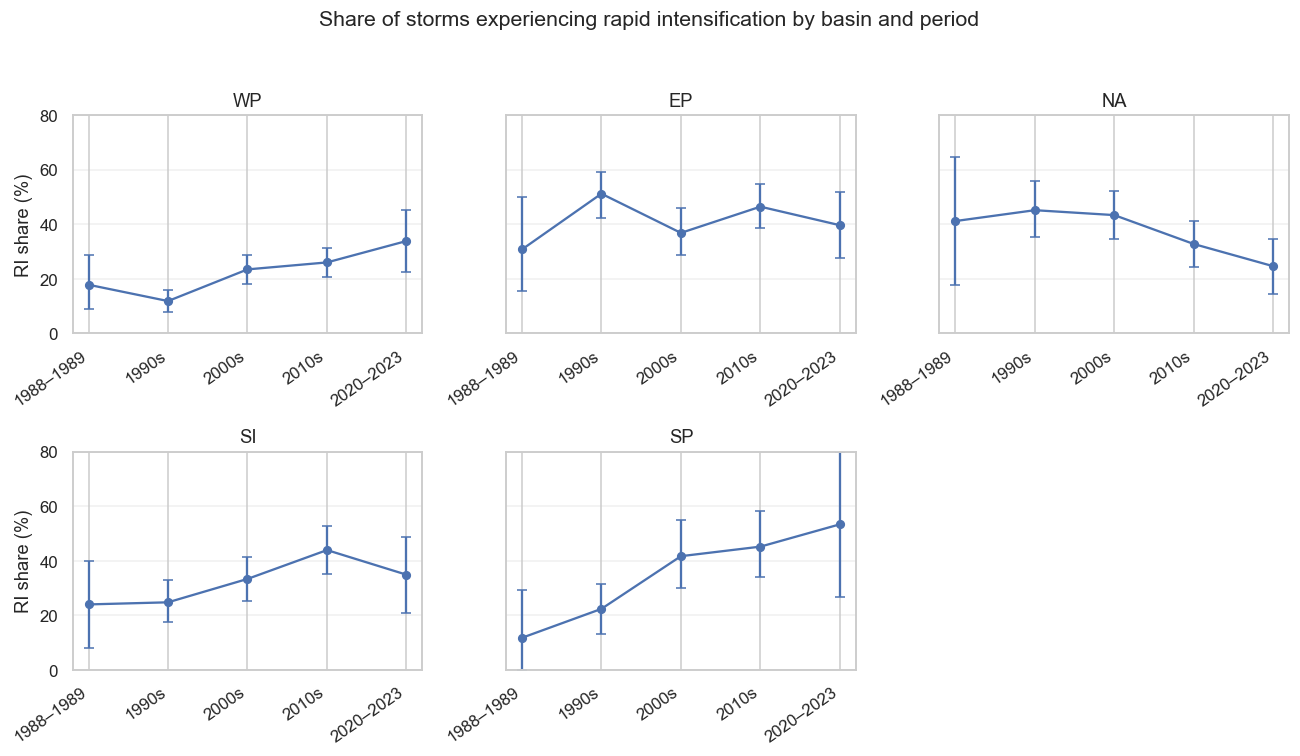

In [17]:
# Plot broad-period RI share with bootstrap confidence intervals

plot_df = decadal_ri.copy()
plot_df["period"] = plot_df["decade"].apply(label_period)

period_order = ["1988–1989", "1990s", "2000s", "2010s", "2020–2023"]
x_positions = {period: i for i, period in enumerate(period_order)}
plot_df["x"] = plot_df["period"].map(x_positions)

y_max = np.ceil(plot_df["ci_upper"].max() / 10) * 10

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, basin in zip(axes, ANALYSIS_BASINS):
    sub = plot_df[plot_df["basin"] == basin].sort_values("x")
    
    yerr = np.vstack([
        sub["ri_share"] - sub["ci_lower"],
        sub["ci_upper"] - sub["ri_share"]
    ])
    
    ax.errorbar(
        sub["x"],
        sub["ri_share"],
        yerr=yerr,
        fmt="o-",
        capsize=3,
        linewidth=1.5,
        markersize=5
    )
    
    ax.set_title(basin)
    ax.set_xticks(range(len(period_order)))
    ax.set_xticklabels(period_order, rotation=35, ha="right")
    ax.set_ylim(0, y_max)
    ax.grid(True, axis="y", alpha=0.3)

# Hide unused sixth subplot
axes[-1].axis("off")

axes[0].set_ylabel("RI share (%)")
axes[3].set_ylabel("RI share (%)")

fig.suptitle(
    "Share of storms experiencing rapid intensification by basin and period",
    fontsize=14,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])


plt.show()

WP, SI and SP look higher in later periods, NA looks lower, and EP shows no consistent direction.
Decade bins can hide yearly patterns, and the first and last periods are incomplete, so the formal trend evidence comes from yearly basin-level shares.

In [18]:
# Yearly RI share by basin

yearly_ri = (
    storms
    .groupby(["basin", "year"])
    .agg(
        n_storms=("experienced_RI", "size"),
        ri_share=("experienced_RI", "mean")
    )
    .reset_index()
)

yearly_ri["ri_share"] *= 100

# Remove very small basin-year cells
yearly_ri = yearly_ri[
    yearly_ri["n_storms"] >= MIN_STORMS_PER_YEAR
].copy()

yearly_ri = yearly_ri.sort_values(["basin", "year"])

print(f"Yearly RI shares computed: {len(yearly_ri)} basin-year cells")
print("\nYears retained per basin:")
print(yearly_ri.groupby("basin").size().reindex(ANALYSIS_BASINS).to_string())

Yearly RI shares computed: 179 basin-year cells

Years retained per basin:
basin
WP    36
EP    36
NA    36
SI    36
SP    35


### Yearly Kendall trend check

The trend test runs on yearly basin-level RI shares. Theil-Sen is the main slope estimate because it is less sensitive to unusual years than OLS. Slopes are reported in percentage points per decade.
OLS is included as a reference. When OLS and Theil-Sen agree on direction, the result is not driven by the slope method. When they disagree, Theil-Sen is used.

In [19]:
trend_results = []

for basin in ANALYSIS_BASINS:
    sub = yearly_ri[yearly_ri["basin"] == basin].sort_values("year")
    
    if len(sub) < 10:
        continue
    
    x = sub["year"].to_numpy()
    y = sub["ri_share"].to_numpy()
    
    # Rank-based trend check
    tau, p_value = stats.kendalltau(x, y)
    
    # Simple descriptive slope
    ols_result = stats.linregress(x, y)
    ols_decade = ols_result.slope * 10
    
    ts_result = stats.theilslopes(y, x, alpha=0.95, method="separate")
    ts_decade = ts_result.slope * 10
    ts_ci_low = ts_result.low_slope * 10
    ts_ci_high = ts_result.high_slope * 10
    
    trend_results.append({
        "Basin": basin,
        "Years": len(sub),
        "Kendall tau": round(tau, 3),
        "p-value": round(p_value, 3),
        "OLS (pp/decade)": round(ols_decade, 2),
        "Theil-Sen (pp/decade)": round(ts_decade, 2),
        "Theil-Sen 95% CI": f"[{round(ts_ci_low, 2)}, {round(ts_ci_high, 2)}]",
    })

trend_ri = pd.DataFrame(trend_results)
display(trend_ri)

,Basin,Years,Kendall tau,p-value,OLS (pp/decade),Theil-Sen (pp/decade),Theil-Sen 95% CI
0,WP,36,0.455,0.000,6.58,6.97,"[3.92, 9.91]"
1,EP,36,-0.056,0.633,-0.98,-1.23,"[-7.14, 4.59]"
2,NA,36,-0.210,0.076,-6.15,-5.83,"[-13.15, 0.0]"
3,SI,36,0.341,0.004,6.29,6.86,"[2.6, 11.11]"
4,SP,35,0.377,0.002,10.36,10.71,"[4.2, 16.71]"


Three basins show clear upward trends in rapid intensification. South Pacific has the largest Theil-Sen estimate at +10.7 pp/decade with 95% CI [4.2, 16.7]. Western Pacific (+7.0 pp/decade, CI [3.9, 9.9]) and South Indian (+6.9 pp/decade, CI [2.6, 11.1]) show smaller but still substantial increases. In all three cases, the confidence intervals exclude zero.

Unlike the high-intensity share results in Notebook 2, OLS and Theil-Sen agree closely here. For WP, SI, and SP, the two slope estimates are very similar, which suggests the upward RI signal is not being driven by a few unusual years pulling the linear fit.

North Atlantic shows a downward tendency that falls just short of significance. Kendall p = 0.076, Theil-Sen -5.8 pp/decade, 95% CI [-13.2, 0.0]. The direction matches the broad period view but doesn't pass the threshold for a clear trend.

Eastern Pacific shows no meaningful trend in either estimate: p = 0.633, Theil-Sen -1.2 pp/decade, with 95% CI crossing zero.

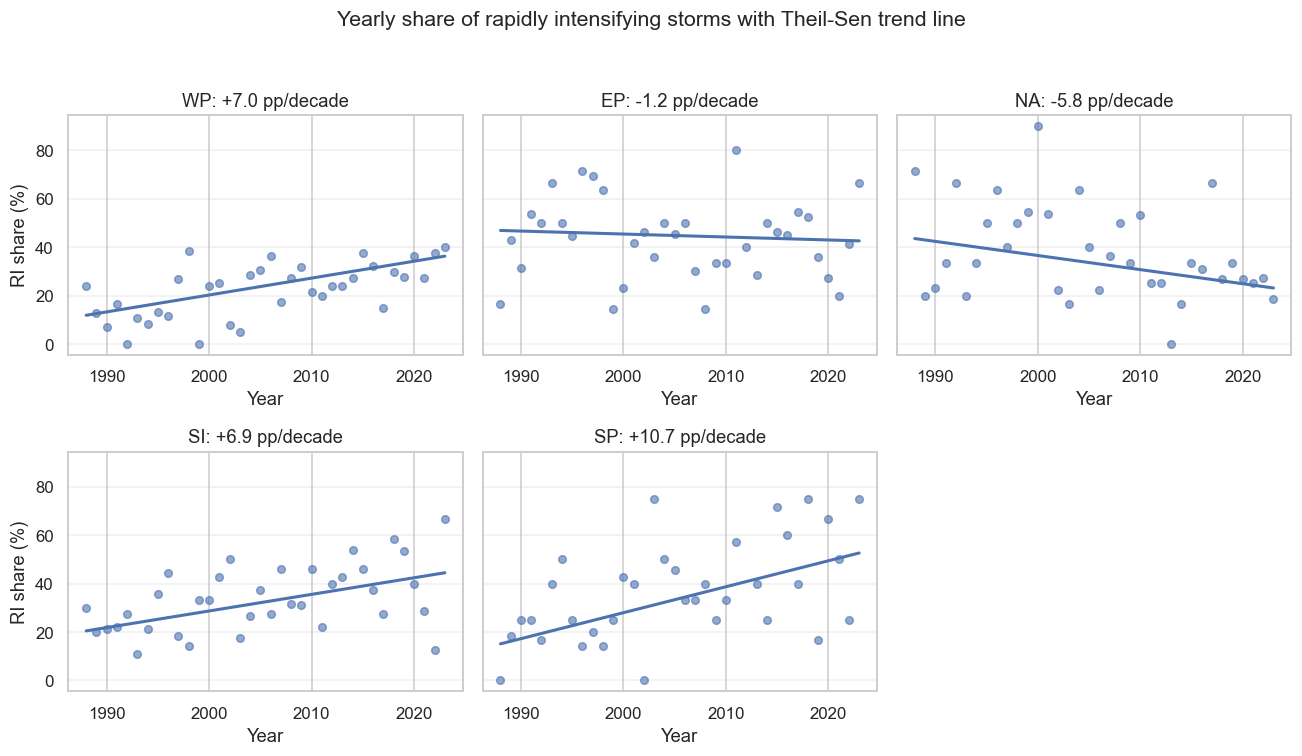

In [20]:
# Yearly rapid-intensification share with Theil-Sen trend line

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, basin in zip(axes, ANALYSIS_BASINS):
    sub = yearly_ri[yearly_ri["basin"] == basin].sort_values("year")
    
    x = sub["year"].to_numpy()
    y = sub["ri_share"].to_numpy()
    
    ax.scatter(x, y, alpha=0.6, s=25)
    
    ts = stats.theilslopes(y, x, alpha=0.95, method="separate")
    
    x_line = np.array([x.min(), x.max()])
    y_line = ts.intercept + ts.slope * x_line
    
    ax.plot(x_line, y_line, linewidth=2)
    
    ax.set_title(f"{basin}: {ts.slope * 10:+.1f} pp/decade")
    ax.set_xlabel("Year")
    ax.grid(True, axis="y", alpha=0.3)

axes[-1].axis("off")

axes[0].set_ylabel("RI share (%)")
axes[3].set_ylabel("RI share (%)")

fig.suptitle(
    "Yearly share of rapidly intensifying storms with Theil-Sen trend line",
    fontsize=14,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The yearly plots support the trend table: clear upward slopes in WP, SI, and SP, flat in EP, and a borderline downward tendency in NA.

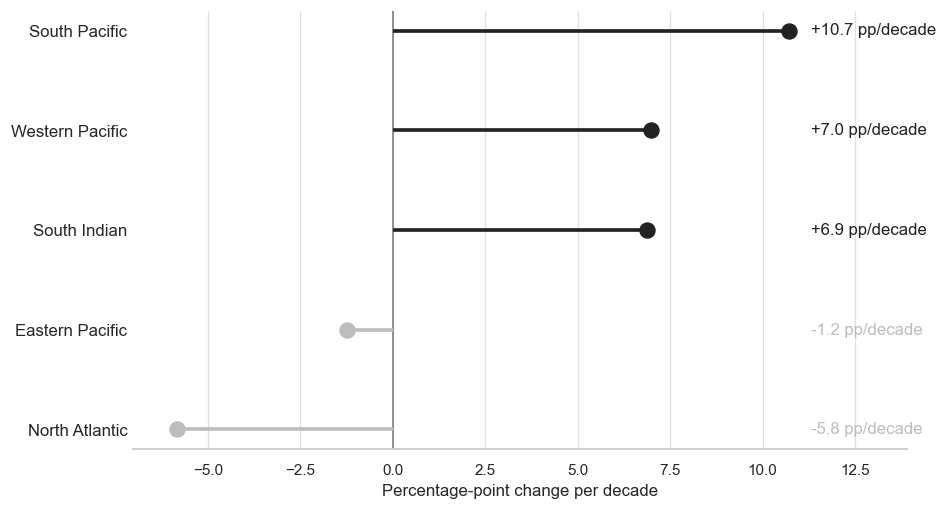

In [21]:
# Build plot data from the trend table
plot_df = trend_ri.copy()

basin_name_map = {
    "WP": "Western Pacific",
    "EP": "Eastern Pacific",
    "NA": "North Atlantic",
    "SI": "South Indian",
    "SP": "South Pacific"
}

plot_df["basin_name"] = plot_df["Basin"].map(basin_name_map)
plot_df["change_pp_per_decade"] = plot_df["Theil-Sen (pp/decade)"]

# Signal labels
plot_df["signal"] = np.where(
    (plot_df["p-value"] < 0.05) & (plot_df["change_pp_per_decade"] > 0),
    "clear upward",
    "no meaningful upward shift"
)


# Order for the chart
plot_df = plot_df.sort_values("change_pp_per_decade", ascending=True)

color_map = {
    "clear upward": "#222222",
    "no meaningful upward shift": "#BDBDBD"
}

fig, ax = plt.subplots(figsize=(8.8, 4.8))

ax.axvline(0, color="#8A8A8A", linewidth=1.2)

# Set x-axis range with room for labels
min_x = plot_df["change_pp_per_decade"].min()
max_x = plot_df["change_pp_per_decade"].max()

ax.set_xlim(min_x - 1.2, max_x + 3.2)
label_x = max_x + 0.6

for _, row in plot_df.iterrows():
    basin = row["basin_name"]
    x = row["change_pp_per_decade"]
    color = color_map[row["signal"]]

    ax.hlines(
        y=basin,
        xmin=min(0, x),
        xmax=max(0, x),
        color=color,
        linewidth=2.4
    )

    ax.scatter(
        x,
        basin,
        color=color,
        s=95,
        zorder=3
    )

    ax.text(
        label_x,
        basin,
        f"{x:+.1f} pp/decade",
        va="center",
        ha="left",
        fontsize=11,
        color=color
    )

ax.set_xlabel("Percentage-point change per decade", fontsize=11)
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

ax.tick_params(axis="y", length=0, labelsize=11)
ax.tick_params(axis="x", labelsize=10)

ax.grid(axis="x", color="#E0E0E0", linewidth=0.8)
ax.grid(axis="y", visible=False)

plt.tight_layout()

plt.show()

### Conclusion

WP, SI, and SP show statistically meaningful upward RI trends. EP shows no meaningful trend. NA shows a borderline downward tendency, not strong enough to treat as definitive. The signal is regional, not global. SP is the strongest RI finding here, even though it was only a sensitivity case for severity in Notebook 2. RI and final storm severity behave as related but separate risk channels.

WP, SI, and SP are the basins where rapid intensification has become more common, so baseline assumptions for forecast uncertainty and preparation time should place more weight on recent decades in those three basins. NA's downward tendency belongs on the watch list rather than being dismissed. EP shows no evidence here requiring a basin-specific RI adjustment.

### Limitations

This notebook is diagnostic of past change, not a forecast. The trend tests show whether RI share has shifted over 1988–2023, but they do not explain what drove the shift or whether it will continue.

The 30 kt / 24 hour RI definition follows common convention, but other thresholds are defensible. A check of threshold sensitivity would be useful to confirm whether the directional findings remain stable under nearby RI definitions.